# 8. Transformer Decoder

**Цель:** Реализовать декодерный блок трансформера: Masked Self-Attention → Cross-Attention → FFN. Понять каузальную маскировку и cross-attention.

---

## 🎭 Мем дня

*Decoder: «Я не подглядываю в будущее». Causal Mask следит за этим строже, чем проктор на экзамене.*

![Мем про decoder](memes/08_decoder.png)


In [1]:
# Transformer Decoder: три под-слоя — Masked Self-Attention, Cross-Attention, FFN
# Masked self-attention: каузальная маска, чтобы токен не видел будущие токены (авторегрессия)
# Cross-attention (перекрёстное внимание): Q от decoder, K и V от encoder — так декодер "читает" выход энкодера
# Каузальная маска: diagonal=1 → верхнетреугольная; -inf, потому что softmax(-inf)=0, а softmax(0)≠0
import sys, os, logging, math

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Вместо logging используем простой print — учебный курс, зачем нам логи?
import builtins as _builtins
def _log(msg, *args):
    if args:
        _builtins.print(msg % args)
    else:
        _builtins.print(msg)

import types
log = types.SimpleNamespace(info=_log, debug=_log, warning=_log, error=_log)



device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Используем устройство: %s", device)

Используем устройство: mps


## 8.1 Каузальная (Causal) маскировка

**Зачем?**
- В декодере каждый токен может "смотреть" только на предыдущие токены
- Нельзя заглядывать в будущее при авторегрессивной генерации

**Реализация:**
- Верхнетреугольная матрица с -inf
- scores[i, j] = -inf для всех j > i (будущие позиции)
- После softmax внимание на будущие позиции = 0

Creating causal mask
Causal mask (True = masked):
[[False  True  True  True  True  True]
 [False False  True  True  True  True]
 [False False False  True  True  True]
 [False False False False  True  True]
 [False False False False False  True]
 [False False False False False False]]


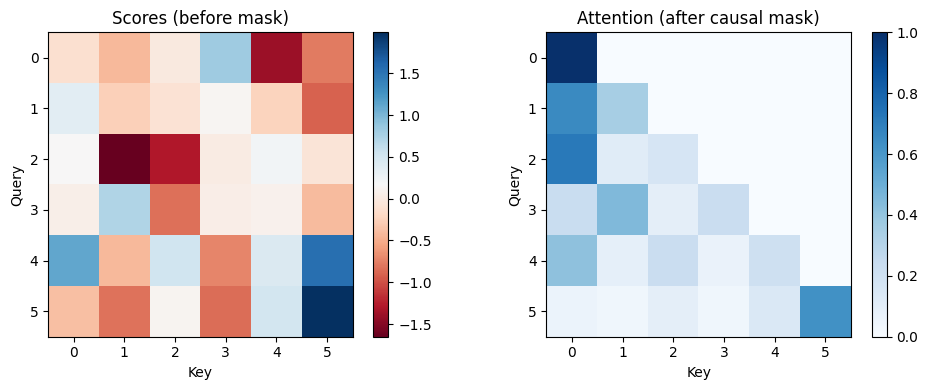

Causal mask demonstration complete


In [2]:
# diagonal=1: единицы НА диагонали НЕ включаются — маскируются только j > i (будущие токены)
# -inf: после softmax маскированные позиции дают ровно 0 внимания (softmax(-inf)=0)
# Если бы поставили 0: softmax(0)≠0, и будущие токены всё равно получали бы ненулевое внимание
log.debug("Creating causal mask")

def create_causal_mask(seq_len):
    """Создаёт каузальную маску (True = маскировать)."""
    mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
    return mask

seq_len = 6
causal_mask = create_causal_mask(seq_len)

print("Causal mask (True = masked):")
print(causal_mask.numpy())

# Демонстрация эффекта на attention
d_k = 8
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
scores_masked = scores.masked_fill(causal_mask.unsqueeze(0), float('-inf'))
attn = F.softmax(scores_masked, dim=-1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(scores[0].detach().numpy(), cmap='RdBu')
axes[0].set_title('Scores (before mask)')
axes[0].set_xlabel('Key')
axes[0].set_ylabel('Query')
plt.colorbar(axes[0].images[0], ax=axes[0], fraction=0.046)

axes[1].imshow(attn[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Attention (after causal mask)')
axes[1].set_xlabel('Key')
axes[1].set_ylabel('Query')
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()
log.info("Causal mask demonstration complete")

## Causal masking: почему будущие токены обнуляются

**Как работает каузальная маска:**
- Маска — верхнетреугольная матрица из `True` для позиций j > i (будущие токены)
- Перед softmax маскированные позиции заполняются `-inf`
- `softmax(-inf) = 0` → внимание на будущие токены становится ровно 0
- Если бы использовали 0 вместо `-inf`: `softmax(0) ≠ 0`, и модель всё равно "видела" бы будущие токены

**Визуализация маски (seq_len=6, True = маскируется):**
```
[[False,  True,  True,  True,  True,  True],   # токен 0 видит только себя
 [False, False,  True,  True,  True,  True],   # токен 1 видит токены 0,1
 [False, False, False,  True,  True,  True],   # токен 2 видит 0,1,2
 [False, False, False, False,  True,  True],
 [False, False, False, False, False,  True],
 [False, False, False, False, False, False]]  # токен 5 видит все предыдущие
```

После softmax все маскированные позиции (True → `-inf`) дают ровно 0 внимания. Модель не может "читерить" и заглядывать в будущие токены при авторегрессивной генерации — каждый токен предсказывается только на основе предыдущих.


## 8.2 MultiHeadAttention (c поддержкой каузальной маски)

Расширяем MHA поддержкой каузальной маски.

In [3]:
# Cross-attention (перекрёстное внимание) в декодере: Q приходит от decoder, K и V — от encoder (разные источники)
# Masked self-attention (causal=True): Q=K=V от decoder, но с каузальной маской
log.debug("Implementing MultiHeadAttention with causal mask support")

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, Q, K, V, mask=None, causal=False):
        batch = Q.size(0)
        Q = self.W_Q(Q).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if causal:
            seq_len = Q.size(-2)
            causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=Q.device), diagonal=1).bool()
            scores = scores.masked_fill(causal_mask.unsqueeze(0).unsqueeze(0), float('-inf'))
        
        if mask is not None:
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        attn = self.dropout(F.softmax(scores, dim=-1))
        output = torch.matmul(attn, V).transpose(1, 2).contiguous().view(batch, -1, self.d_model)
        return self.W_O(output), attn

mha = MultiHeadAttention(d_model=32, n_heads=4)
x = torch.randn(2, 10, 32)
out, attn = mha(x, x, x, causal=True)
log.info("Causal MHA forward pass OK, output=%s, attention=%s", out.shape, attn.shape)

Implementing MultiHeadAttention with causal mask support
Causal MHA forward pass OK, output=torch.Size([2, 10, 32]), attention=torch.Size([2, 4, 10, 10])


## 8.3 FeedForward (из предыдущего ноутбука)

In [4]:
# Третий под-слой декодера: Position-wise Feed-Forward Network (после self-attn и cross-attn)
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None, dropout=0.1):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.fc2(self.dropout(F.gelu(self.fc1(x))))

ffn = FeedForward(32)
log.debug("FeedForward module ready")

FeedForward module ready


## 8.4 TransformerDecoderBlock

**Три под-слоя (против двух в энкодере):**
1. Masked Self-Attention (каузальный) → Add & Norm
2. Cross-Attention (Q от декодера, K, V от энкодера) → Add & Norm
3. Feed-Forward Network → Add & Norm

In [5]:
# Первый self-attention маскирован (causal=True): авторегрессия — токен не может заглядывать в будущее
# Второй — cross-attention: Q=decoder, K,V=encoder — связь с закодированным входом
# Третий — FFN (position-wise)
log.debug("Implementing TransformerDecoderBlock")

class TransformerDecoderBlock(nn.Module):
    """Один блок декодера трансформера."""
    
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        # Self-attention (causal — причинное)
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        
        # Cross-attention (перекрёстное внимание)
        self.cross_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)
        
        # FFN (полносвязная сеть)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout3 = nn.Dropout(dropout)
        
        log.debug("DecoderBlock: d_model=%d, n_heads=%d", d_model, n_heads)
    
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # 1. Masked Self-Attention (маскированное самовнимание)
        attn_out, self_attn = self.self_attention(self.norm1(x), self.norm1(x), self.norm1(x),
                                                  mask=tgt_mask, causal=True)
        x = x + self.dropout1(attn_out)
        
        # 2. Cross-Attention: Q=декодер, K,V=энкодер
        cross_out, cross_attn = self.cross_attention(self.norm2(x),
                                                     self.norm2(encoder_output),
                                                     self.norm2(encoder_output),
                                                     mask=src_mask)
        x = x + self.dropout2(cross_out)
        
        # 3. FFN (полносвязная сеть)
        ffn_out = self.ffn(self.norm3(x))
        x = x + self.dropout3(ffn_out)
        
        return x, self_attn, cross_attn

decoder_block = TransformerDecoderBlock(d_model=32, n_heads=4)
log.info("TransformerDecoderBlock created")

Implementing TransformerDecoderBlock
DecoderBlock: d_model=32, n_heads=4
TransformerDecoderBlock created


## Cross-attention: как encoder передаёт информацию decoder'у

**Механизм cross-attention:**
- **Q (Query)** — от декодера (текущая целевая последовательность)
- **K (Key) и V (Value)** — от энкодера (закодированный вход, например, предложение на исходном языке)
- Каждая позиция декодера вычисляет внимание ко ВСЕМ позициям энкодера
- Результат: взвешенная сумма encoder-представлений, где вес = релевантность текущего decoder-запроса к каждой encoder-позиции

**Почему это важно:**
- Cross-attention — единственный канал, через который encoder передаёт информацию decoder'у
- Без него decoder работал бы "вслепую", только на основе предыдущих сгенерированных токенов
- В отличие от self-attention, здесь нет каузальной маски — decoder может attend к любой части входа

**Сравнение с self-attention:**
| Свойство | Self-Attention (causal) | Cross-Attention |
|---|---|---|
| Q, K, V откуда? | Все от decoder | Q от decoder, K,V от encoder |
| Маска | Каузальная (верхнетреугольная) | Нет маски |
| Размер матрицы | seq_len_dec × seq_len_dec | seq_len_dec × seq_len_enc |
| Назначение | Учёт контекста генерации | "Чтение" входа энкодера |


In [6]:
# Прямой проход: декодер получает target sequence (x) и выход энкодера (представление входа)
# Self-attention: causal — нижнетреугольная; Cross-attention: каждый decoder токен attends ко всем encoder позициям
log.debug("Testing decoder block forward pass")

batch, seq_len_dec, seq_len_enc, d_model = 2, 8, 12, 32
x = torch.randn(batch, seq_len_dec, d_model)
encoder_out = torch.randn(batch, seq_len_enc, d_model)

output, self_attn, cross_attn = decoder_block(x, encoder_out)

print(f"Decoder input:        {x.shape}")
print(f"Encoder output:       {encoder_out.shape}")
print(f"Decoder output:       {output.shape}")
print(f"Self-attention:       {self_attn.shape}")
print(f"Cross-attention:      {cross_attn.shape}")
log.info("Decoder block forward pass OK")

Testing decoder block forward pass
Decoder input:        torch.Size([2, 8, 32])
Encoder output:       torch.Size([2, 12, 32])
Decoder output:       torch.Size([2, 8, 32])
Self-attention:       torch.Size([2, 4, 8, 8])
Cross-attention:      torch.Size([2, 4, 8, 12])
Decoder block forward pass OK


## 8.5 Стекирование: TransformerDecoder

In [7]:
# Стекирование N decoder block'ов: каждый слой получает выход предыдущего
log.debug("Implementing TransformerDecoder")

class TransformerDecoder(nn.Module):
    def __init__(self, num_layers, d_model, n_heads, d_ff=None, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerDecoderBlock(d_model, n_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        log.debug("TransformerDecoder: %d layers", num_layers)
    
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        all_self_attns = []
        all_cross_attns = []
        for i, layer in enumerate(self.layers):
            log.debug("Decoder layer %d forward", i)
            x, self_attn, cross_attn = layer(x, encoder_output, src_mask, tgt_mask)
            all_self_attns.append(self_attn)
            all_cross_attns.append(cross_attn)
        return x, all_self_attns, all_cross_attns

decoder = TransformerDecoder(num_layers=4, d_model=32, n_heads=4)
output, self_attns, cross_attns = decoder(x, encoder_out)
print(f"Decoder output:     {output.shape}")
print(f"Self-attention maps: {len(self_attns)}")
print(f"Cross-attention maps: {len(cross_attns)}")
log.info("TransformerDecoder forward pass OK")

Implementing TransformerDecoder
DecoderBlock: d_model=32, n_heads=4
DecoderBlock: d_model=32, n_heads=4
DecoderBlock: d_model=32, n_heads=4
DecoderBlock: d_model=32, n_heads=4
TransformerDecoder: 4 layers
Decoder layer 0 forward
Decoder layer 1 forward
Decoder layer 2 forward
Decoder layer 3 forward
Decoder output:     torch.Size([2, 8, 32])
Self-attention maps: 4
Cross-attention maps: 4
TransformerDecoder forward pass OK


## 8.6 Визуализация: Causal Mask в действии

Сравниваем self-attention (causal) vs cross-attention.

Visualizing causal vs cross attention patterns
Decoder layer 0 forward
Decoder layer 1 forward


Decoder layer 2 forward
Decoder layer 3 forward


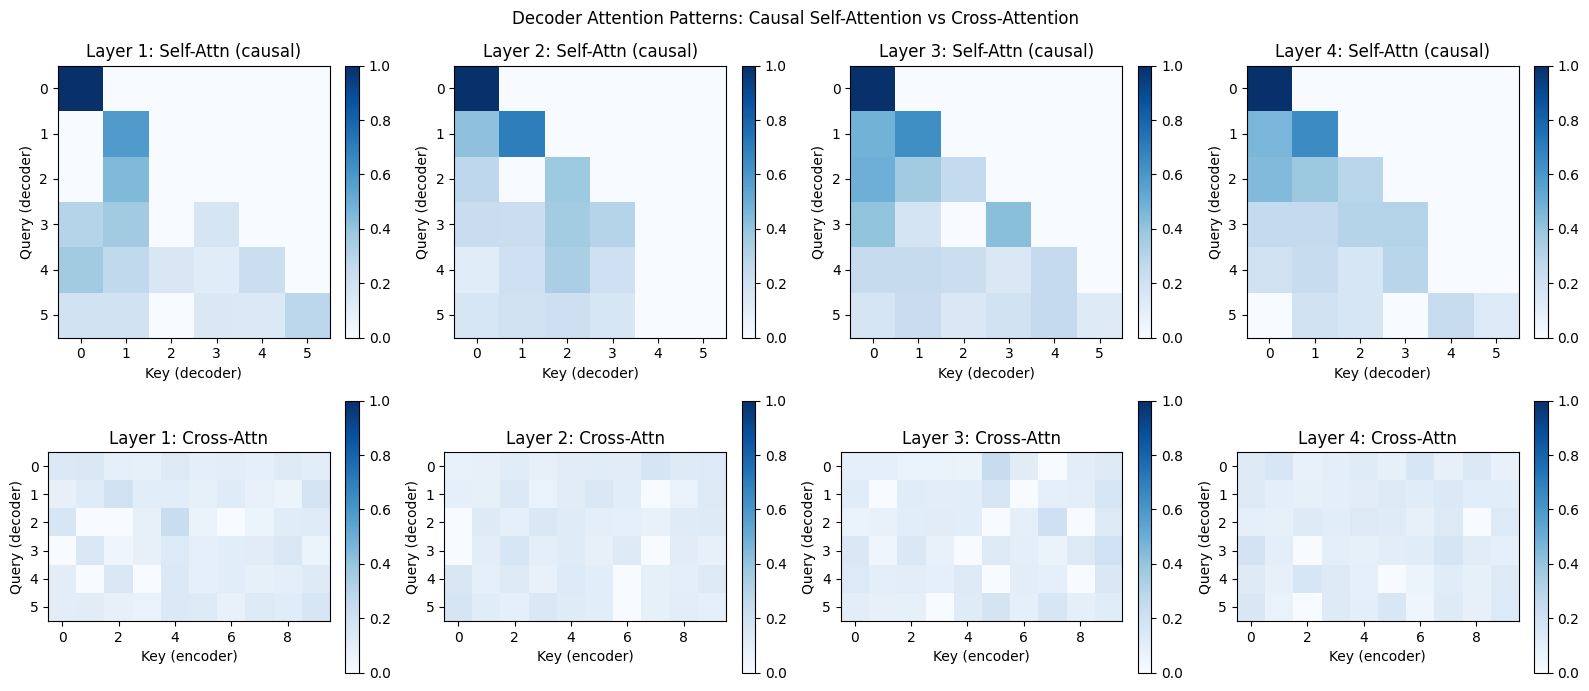

Decoder attention visualization complete


In [8]:
# Self-attention (causal — причинное): нижнетреугольная матрица — токен видит только себя и прошлые
# Cross-attention (перекрёстное внимание): полная матрица — каждый decoder токен attends ко ВСЕМ encoder позициям
log.debug("Visualizing causal vs cross attention patterns")

x = torch.randn(1, 6, 32)
enc_out = torch.randn(1, 10, 32)

out, self_attns, cross_attns = decoder(x, enc_out)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i in range(4):
    # Self-attention (causal — причинное), head 0
    im = axes[0, i].imshow(self_attns[i][0, 0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    axes[0, i].set_title(f'Layer {i+1}: Self-Attn (causal)')
    axes[0, i].set_xlabel('Key (decoder)')
    axes[0, i].set_ylabel('Query (decoder)')
    plt.colorbar(im, ax=axes[0, i], fraction=0.046)
    
    # Cross-attention (перекрёстное внимание) (no mask)
    im = axes[1, i].imshow(cross_attns[i][0, 0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    axes[1, i].set_title(f'Layer {i+1}: Cross-Attn')
    axes[1, i].set_xlabel('Key (encoder)')
    axes[1, i].set_ylabel('Query (decoder)')
    plt.colorbar(im, ax=axes[1, i], fraction=0.046)

plt.suptitle('Decoder Attention Patterns: Causal Self-Attention vs Cross-Attention')
plt.tight_layout()
plt.show()
log.info("Decoder attention visualization complete")

In [9]:
# Декодер: (1) Masked Self-Attention → (2) Cross-Attention → (3) FFN
print("=== Transformer Decoder complete ===")
print("Topics covered:")
print("  - Causal (masked) self-attention")
print("  - Cross-attention: Q from decoder, K,V from encoder")
print("  - TransformerDecoderBlock (3 sub-layers)")
print("  - Stacked TransformerDecoder")
print("  - Causal vs cross-attention visualization")
print("  - Difference from encoder (causal mask + cross-attention)")
log.info("Decoder notebook complete")

=== Transformer Decoder complete ===
Topics covered:
  - Causal (masked) self-attention
  - Cross-attention: Q from decoder, K,V from encoder
  - TransformerDecoderBlock (3 sub-layers)
  - Stacked TransformerDecoder
  - Causal vs cross-attention visualization
  - Difference from encoder (causal mask + cross-attention)
Decoder notebook complete


📚 **Полезные ссылки:**
- [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762) — раздел про Decoder
